In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

In [38]:
df = pd.read_csv('molecule_data_with_embeddings.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df

Shape: (133885, 46)
Columns: ['mol_id', 'smiles', 'dipole_moment', 'polarizability', 'homo_energy', 'lumo_energy', 'homo_lumo_gap', 'spatial_extent', 'zero_point_energy', 'internal_energy_0K', 'heat_capacity', 'internal_energy_298K', 'enthalpy_298K', 'free_energy_298K', 'emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7', 'emb_8', 'emb_9', 'emb_10', 'emb_11', 'emb_12', 'emb_13', 'emb_14', 'emb_15', 'emb_16', 'emb_17', 'emb_18', 'emb_19', 'emb_20', 'emb_21', 'emb_22', 'emb_23', 'emb_24', 'emb_25', 'emb_26', 'emb_27', 'emb_28', 'emb_29', 'emb_30', 'emb_31']


,mol_id,smiles,dipole_moment,polarizability,homo_energy,lumo_energy,homo_lumo_gap,spatial_extent,zero_point_energy,internal_energy_0K,...,emb_22,emb_23,emb_24,emb_25,emb_26,emb_27,emb_28,emb_29,emb_30,emb_31
0,gdb_1,C,0.0000,13.21,-0.3877,0.1171,0.5048,35.3641,0.044749,-40.478930,...,66.889565,74.292000,67.587395,73.561287,62.723698,56.246952,80.455521,44.738461,75.804459,50.751362
1,gdb_2,N,1.6256,9.46,-0.2570,0.0829,0.3399,26.1563,0.034358,-56.525887,...,74.315887,84.190201,72.616272,83.858437,69.818726,63.885220,90.207726,49.592896,85.834602,58.532761
2,gdb_3,O,1.8511,6.31,-0.2928,0.0687,0.3615,19.0002,0.021375,-76.404702,...,78.193756,86.519569,74.758965,90.668610,73.020248,69.327774,94.252182,52.189442,89.349175,62.142277
3,gdb_4,C#C,0.0000,16.28,-0.2845,0.0506,0.3351,59.5248,0.026841,-77.308427,...,59.247391,68.571976,59.487873,63.880550,55.292271,48.462475,73.449974,38.684883,68.620743,45.738834
4,gdb_5,C#N,2.8937,12.99,-0.3604,0.0191,0.3796,48.7476,0.016601,-93.411888,...,74.558434,85.129692,74.082298,82.315018,69.663643,62.765148,91.308609,48.668285,85.778664,58.078968
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133880,gdb_133881,C1C2C3C4C5OC14C5N23,1.6637,69.37,-0.2254,0.0588,0.2842,760.7472,0.127406,-400.633868,...,44.872505,49.348637,41.772667,53.868687,41.762131,43.387142,51.171440,32.849998,46.912022,36.491936
133881,gdb_133882,C1N2C3C2C2C4OC12C34,1.2976,69.52,-0.2393,0.0608,0.3002,762.6354,0.127495,-400.629713,...,44.407768,48.759277,41.160797,53.391323,41.216805,42.994102,50.536491,32.613544,46.399792,36.220692
133882,gdb_133883,C1N2C3C4C5C2C13CN45,1.2480,73.60,-0.2233,0.0720,0.2953,780.3553,0.140458,-380.753918,...,43.239254,48.004795,41.037941,51.098816,40.422974,41.188324,50.165428,31.524588,46.048203,34.970955
133883,gdb_133884,C1N2C3C4C5CC13C2C45,1.9576,77.40,-0.2122,0.0881,0.3003,803.1904,0.152222,-364.720374,...,44.972660,50.717060,43.864834,52.350235,42.718632,42.161434,52.882389,32.763218,48.423462,36.044872


______________________________

In [39]:
print(df.dtypes)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values')
print(f'\nDuplicate rows: {df.duplicated().sum()}')
print(f'Duplicate SMILES: {df.smiles.duplicated().sum()}')

mol_id                   object
smiles                   object
dipole_moment           float64
polarizability          float64
homo_energy             float64
lumo_energy             float64
homo_lumo_gap           float64
spatial_extent          float64
zero_point_energy       float64
internal_energy_0K      float64
heat_capacity           float64
internal_energy_298K    float64
enthalpy_298K           float64
free_energy_298K        float64
emb_0                   float64
emb_1                   float64
emb_2                   float64
emb_3                   float64
emb_4                   float64
emb_5                   float64
emb_6                   float64
emb_7                   float64
emb_8                   float64
emb_9                   float64
emb_10                  float64
emb_11                  float64
emb_12                  float64
emb_13                  float64
emb_14                  float64
emb_15                  float64
emb_16                  float64
emb_17  

In [40]:
property_cols = ['dipole_moment', 'polarizability', 'homo_energy', 'lumo_energy',
                 'homo_lumo_gap', 'spatial_extent', 'zero_point_energy',
                 'internal_energy_0K', 'heat_capacity', 'internal_energy_298K',
                 'enthalpy_298K', 'free_energy_298K']
emb_cols = [c for c in df.columns if c.startswith('emb_')]
print(f'Property columns: {len(property_cols)}')
print(f'Embedding columns: {len(emb_cols)}')
df[property_cols].describe().T.style.background_gradient(cmap='YlOrRd')

Property columns: 12
Embedding columns: 32


,count,mean,std,min,25%,50%,75%,max
dipole_moment,133885.000000,2.706037,1.530394,0.000000,1.588700,2.500000,3.636100,29.556400
polarizability,133885.000000,75.191296,8.187793,6.310000,70.380000,75.500000,80.520000,196.620000
homo_energy,133885.000000,-0.239977,0.022131,-0.428600,-0.252500,-0.241000,-0.228700,-0.101700
lumo_energy,133885.000000,0.011124,0.046936,-0.175000,-0.023800,0.012000,0.049200,0.193500
homo_lumo_gap,133885.000000,0.251100,0.047519,0.024600,0.216300,0.249400,0.288200,0.622100
spatial_extent,133885.000000,1189.527450,279.757172,19.000200,1018.322600,1147.585800,1308.816600,3374.753200
zero_point_energy,133885.000000,0.148524,0.033274,0.015951,0.125289,0.148329,0.171150,0.273944
internal_energy_0K,133885.000000,-411.543985,40.060230,-714.568061,-437.913936,-417.864758,-387.049166,-40.478930
heat_capacity,133885.000000,31.600676,4.062471,6.002000,28.942000,31.555000,34.276000,46.969000
internal_energy_298K,133885.000000,-411.535513,40.060012,-714.560153,-437.905942,-417.857351,-387.039746,-40.476062


In [41]:
print(f'Before: {len(df)} rows')
dup_mask = df['smiles'].duplicated(keep=False)
df = df.drop_duplicates(subset='smiles', keep='first').reset_index(drop=True)
print(f'After: {len(df)} rows')

Before: 133885 rows
After: 133802 rows


______________________________

In [42]:
smiles_series = df['smiles'].copy()
mol_ids = df['mol_id'].copy()
df = df.drop(columns=['mol_id', 'smiles'])
print(f'remain: {len(df.columns)} are all numeric? {df.select_dtypes(include=[np.number]).shape[1] == df.shape[1]})')

remain: 44 are all numeric? True)


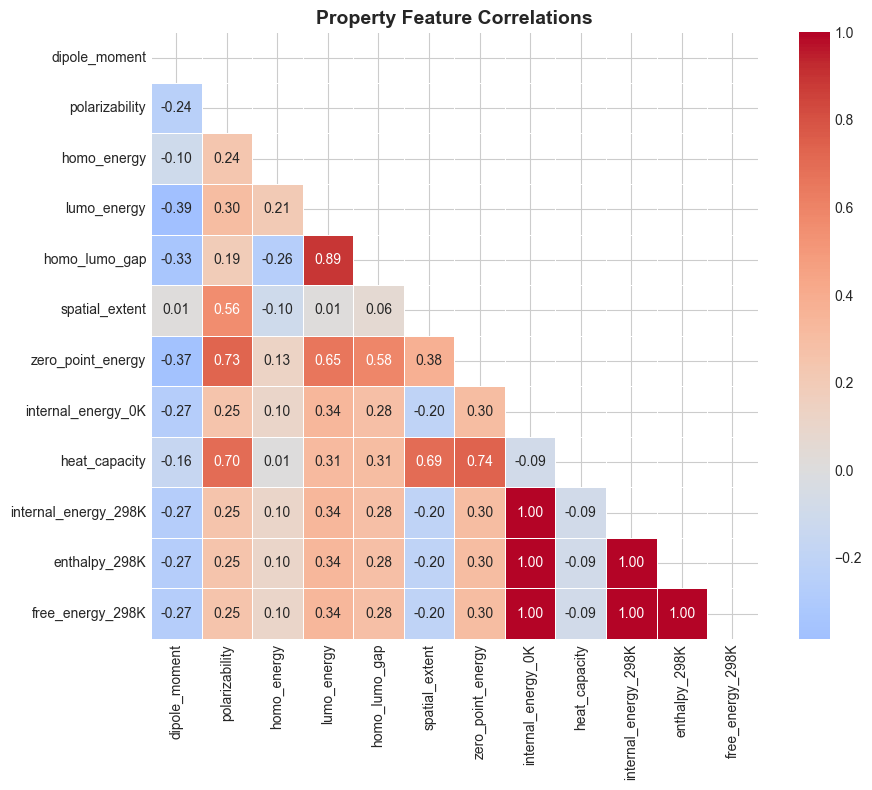

In [43]:
prop_cols_current = [c for c in property_cols if c in df.columns]
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[prop_cols_current].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Property Feature Correlations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [44]:
cols = corr.columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        if abs(corr.iloc[i, j]) > 0.95:
            print(f'  {cols[i]} - {cols[j]}: r = {corr.iloc[i, j]:.4f}')

  internal_energy_0K - internal_energy_298K: r = 1.0000
  internal_energy_0K - enthalpy_298K: r = 1.0000
  internal_energy_0K - free_energy_298K: r = 1.0000
  internal_energy_298K - enthalpy_298K: r = 1.0000
  internal_energy_298K - free_energy_298K: r = 1.0000
  enthalpy_298K - free_energy_298K: r = 1.0000


In [45]:
redundant = ['internal_energy_298K', 'enthalpy_298K', 'free_energy_298K']
df = df.drop(columns=redundant)
property_cols = [c for c in property_cols if c not in redundant]
print(f'Dropped: {redundant}')
print(f'Remaining property columns: {property_cols}')

Dropped: ['internal_energy_298K', 'enthalpy_298K', 'free_energy_298K']
Remaining property columns: ['dipole_moment', 'polarizability', 'homo_energy', 'lumo_energy', 'homo_lumo_gap', 'spatial_extent', 'zero_point_energy', 'internal_energy_0K', 'heat_capacity']


_____________________________________

  wear dipole_moment: 1.460
  wear spatial_extent: 1.293
  ok internal_energy_0K: 0.316
  ok homo_energy: 0.267
  ok zero_point_energy: 0.011
  ok homo_lumo_gap: -0.006
  ok heat_capacity: -0.063
  ok lumo_energy: -0.183
  ok polarizability: -0.382


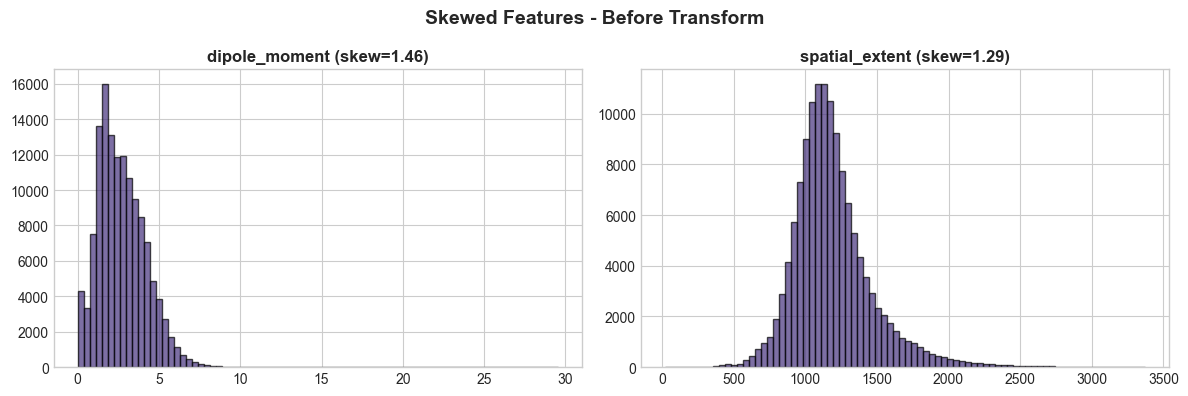

In [46]:
skewness = df[property_cols].skew().sort_values(ascending=False)
for col, val in skewness.items():
    print(f'  {"wear" if abs(val) > 1.0 else "ok"} {col}: {val:.3f}')

skewed_props = skewness[abs(skewness) > 1.0].index.tolist()
if skewed_props:
    fig, axes = plt.subplots(1, len(skewed_props), figsize=(6*len(skewed_props), 4))
    if len(skewed_props) == 1: axes = [axes]
    for ax, col in zip(axes, skewed_props):
        ax.hist(df[col], bins=80, edgecolor='black', alpha=0.7)
        ax.set_title(f'{col} (skew={df[col].skew():.2f})', fontweight='bold')
    plt.suptitle('Skewed Features - Before Transform', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [47]:
log_cols = [c for c in skewed_props if df[c].min() >= 0]
print(f'Applying log1p to: {log_cols}')
for col in log_cols:
    before = df[col].skew()
    df[col] = np.log1p(df[col])
    print(f'  {col}: skew {before:.3f} : {df[col].skew():.3f}')

Applying log1p to: ['dipole_moment', 'spatial_extent']
  dipole_moment: skew 1.460 : -0.312
  spatial_extent: skew 1.293 : -0.172


---

In [48]:
all_numeric = df.columns.tolist()
total_capped = 0
for col in all_numeric:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n = ((df[col] < lower) | (df[col] > upper)).sum()
    total_capped += n
    df[col] = df[col].clip(lower=lower, upper=upper)

print(f'Total values capped: {total_capped}')

Total values capped: 252312


---

In [49]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)
for col in property_cols:
    print(f'  {col}: mean={df_scaled[col].mean():.4f}, std={df_scaled[col].std():.4f}')
print(f'\nEmbedding means range: [{df_scaled[emb_cols].mean().min():.4f}, {df_scaled[emb_cols].mean().max():.4f}]')

  dipole_moment: mean=-0.0000, std=1.0000
  polarizability: mean=-0.0000, std=1.0000
  homo_energy: mean=-0.0000, std=1.0000
  lumo_energy: mean=0.0000, std=1.0000
  homo_lumo_gap: mean=0.0000, std=1.0000
  spatial_extent: mean=-0.0000, std=1.0000
  zero_point_energy: mean=-0.0000, std=1.0000
  internal_energy_0K: mean=0.0000, std=1.0000
  heat_capacity: mean=-0.0000, std=1.0000

Embedding means range: [-0.0000, 0.0000]


---

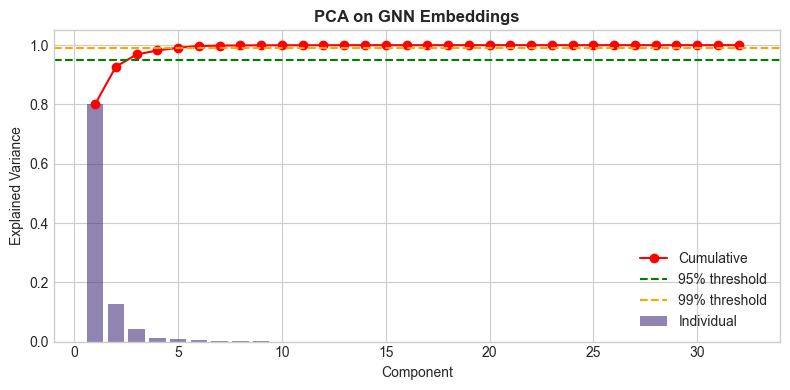

Components for 95% variance: 3
Components for 99% variance: 5


In [ ]:
'''pca_full = PCA().fit(df_scaled[emb_cols])
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(cumvar)+1), pca_full.explained_variance_ratio_, alpha=0.6, label='Individual')
ax.plot(range(1, len(cumvar)+1), cumvar, 'ro-', label='Cumulative')
ax.axhline(y=0.95, color='g', linestyle='--', label='95% threshold')
ax.axhline(y=0.99, color='orange', linestyle='--', label='99% threshold')
ax.set_xlabel('Component'); ax.set_ylabel('Explained Variance')
ax.set_title('PCA on GNN Embeddings', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

n95 = np.argmax(cumvar >= 0.95) + 1
n99 = np.argmax(cumvar >= 0.99) + 1
print(f'Components for 95% variance: {n95}')
print(f'Components for 99% variance: {n99}')'''

In [50]:
df_final

,dipole_moment,polarizability,homo_energy,lumo_energy,homo_lumo_gap,spatial_extent,zero_point_energy,internal_energy_0K,heat_capacity,emb_pca_0,emb_pca_1,emb_pca_2,emb_pca_3,emb_pca_4
0,-2.779445,-2.558201,-2.357302,2.258574,3.054879,-2.429110,-2.781004,2.641233,-2.668369,-11.674288,-1.460956,-0.544788,0.639352,0.000016
1,-0.631667,-2.558201,-0.825630,1.529400,1.871122,-2.429110,-2.781004,2.641233,-2.668369,-12.058836,-1.340295,-0.115256,0.595630,0.187659
2,-0.432395,-2.558201,-2.357302,1.226643,2.326494,-2.429110,-2.781004,2.641233,-2.668369,-11.721710,-1.307610,0.929251,0.262097,-0.857965
3,-2.779445,-2.558201,-2.175662,0.840734,1.769928,-2.429110,-2.781004,2.641233,-2.668369,-5.624452,-2.845315,-2.985806,1.121485,-0.285324
4,0.321336,-2.558201,-2.357302,0.169126,2.708079,-2.429110,-2.781004,2.641233,-2.668369,-12.058836,-1.340295,-0.115256,0.595630,0.187659
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133797,-0.596825,-0.750303,0.725679,1.015566,0.696851,-2.021496,-0.638719,0.289316,-1.989865,8.273040,1.328139,-0.239878,0.432756,0.353674
133798,-0.954400,-0.731205,0.043299,1.058208,1.034164,-2.009604,-0.636028,0.289425,-1.980109,8.685370,1.007063,-0.283296,0.331591,0.447449
133799,-1.007181,-0.211753,0.828772,1.297002,0.930862,-1.899412,-0.244194,0.809510,-1.911321,9.519582,0.002754,-1.470877,0.286457,0.109666
133800,-0.343702,0.272051,1.373694,1.640268,1.036272,-1.761039,0.111397,1.229056,-1.705206,7.778384,0.676657,-1.702899,0.313681,-0.373492


---

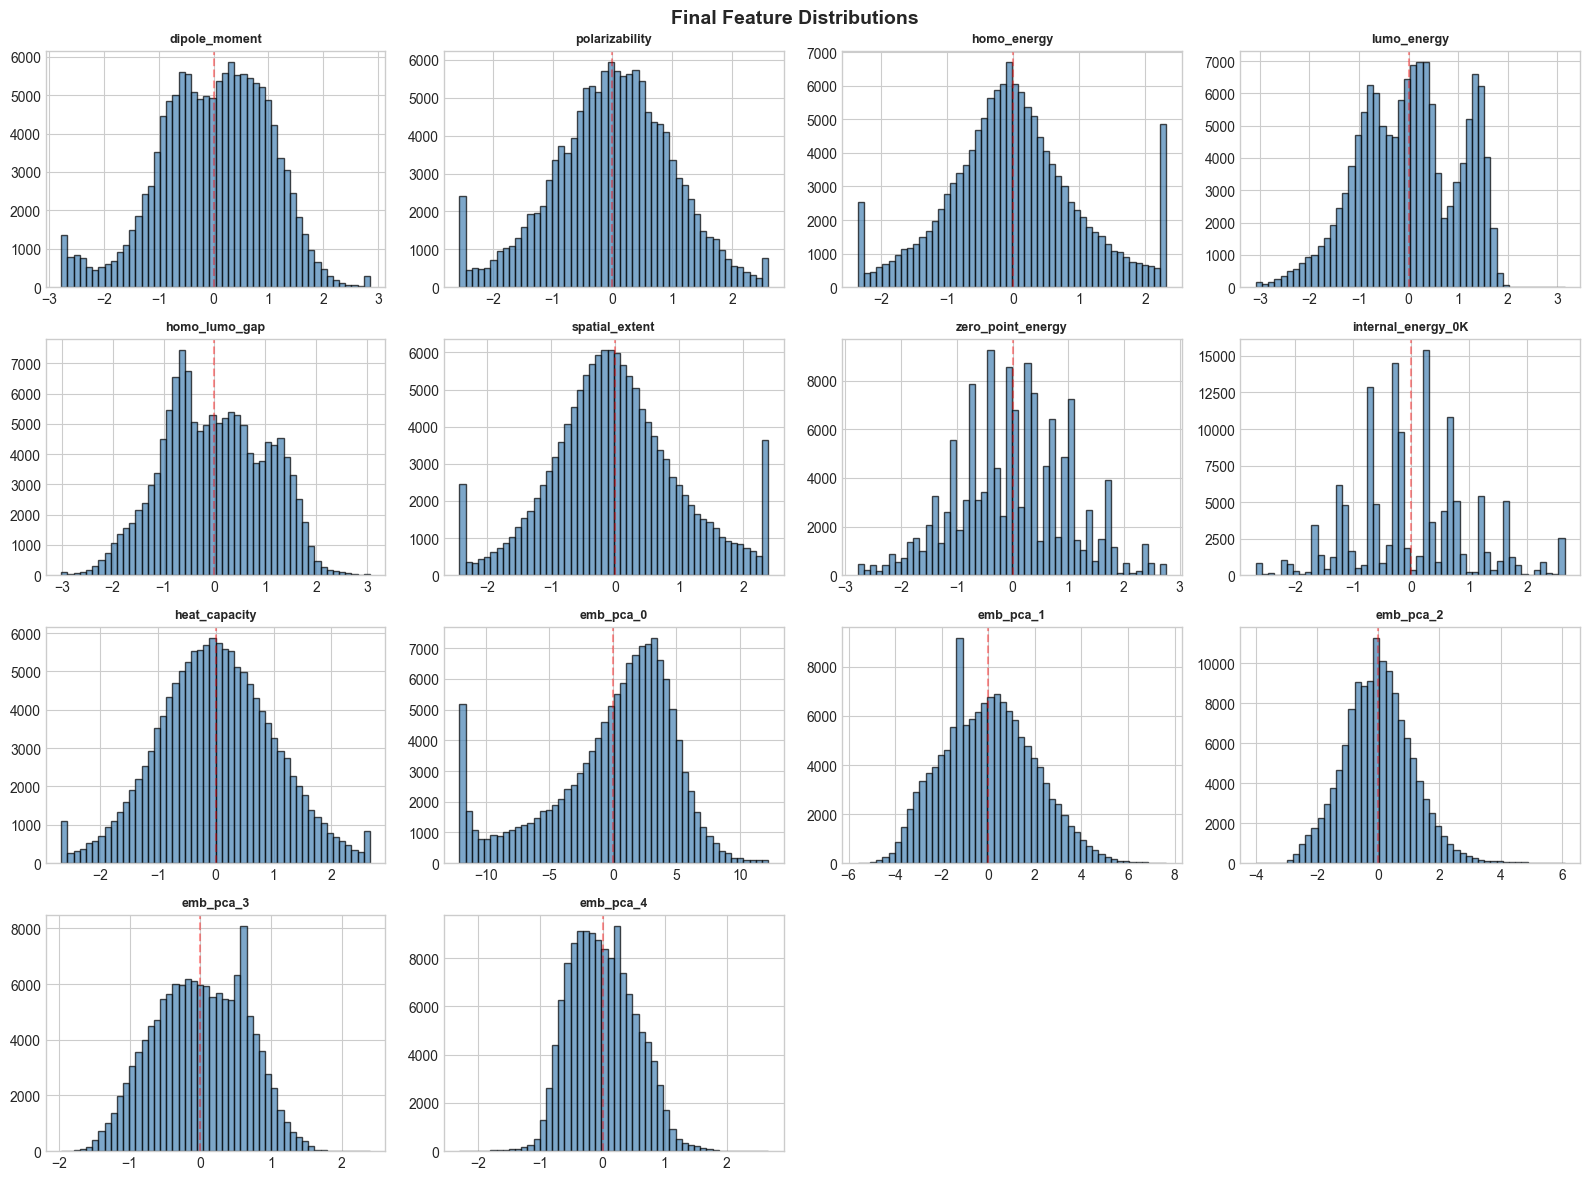

In [ ]:
'''n_cols = len(df_final.columns)
n_rows_plot = (n_cols + 3) // 4
fig, axes = plt.subplots(n_rows_plot, 4, figsize=(16, 3*n_rows_plot))
axes = axes.ravel()
for i, col in enumerate(df_final.columns):
    axes[i].hist(df_final[col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].axvline(0, color='red', linestyle='--', alpha=0.4)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Final Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()'''